<a href="https://colab.research.google.com/github/sabascodes/Logistics-project/blob/main/demand_model_improved.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Barakah Logistics – Demand Forecasting
Predicts how many units will be sold per day for each city + product category, up to 7 days ahead. The `forecast_demand()` function at the end is what the AI agent will call.

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
from google.colab import files
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

Saving barakah_demand_dataset.csv to barakah_demand_dataset.csv


## 1. Settings

In [3]:
MODEL_PATH = "demand_model.joblib"
RANDOM_STATE = 42
SPLIT_DATE = "2026-01-01"   # train on dates before this, test on dates after
HORIZON = 7                 # we forecast up to 7 days ahead
TARGET = "units_sold"

## 2. Load data and create features

In [4]:
df = pd.read_csv(file_name, parse_dates=["date"])
df = df.sort_values(["city", "category", "date"]).reset_index(drop=True)
df.head()

,date,city,category,units_sold,unit_price_sar,promo_flag,discount_pct,avg_temp_c,is_weekend,is_pre_ramadan,is_ramadan,is_pre_eid_fitr,is_eid_adha,is_hajj_season,is_white_friday,is_national_day,is_school_season,is_salary_week
0,2022-01-01,Dammam,Clothing & Fashion,244,138.36,0,0,11.5,1,0,0,0,0,0,0,0,0,1
1,2022-01-02,Dammam,Clothing & Fashion,186,138.71,0,0,16.1,0,0,0,0,0,0,0,0,0,0
2,2022-01-03,Dammam,Clothing & Fashion,164,140.85,0,0,10.7,0,0,0,0,0,0,0,0,0,0
3,2022-01-04,Dammam,Clothing & Fashion,147,140.96,0,0,14.8,0,0,0,0,0,0,0,0,0,0
4,2022-01-05,Dammam,Clothing & Fashion,172,143.05,0,0,14.3,0,0,0,0,0,0,0,0,0,0


In [5]:
# calendar features
df["month"] = df["date"].dt.month
df["day_of_week"] = df["date"].dt.dayofweek
df["day_of_month"] = df["date"].dt.day
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)

**Lag features** = what demand looked like in the past, per city + category.
`shift(HORIZON)` means we only use data that is at least 7 days old, so the model never sees the future.

In [6]:
grp = df.groupby(["city", "category"])[TARGET]
df["lag_7"]  = grp.shift(HORIZON)
df["lag_14"] = grp.shift(HORIZON + 7)
df["lag_28"] = grp.shift(HORIZON + 21)
df["roll_mean_7"]  = grp.transform(lambda s: s.shift(HORIZON).rolling(7).mean())
df["roll_mean_28"] = grp.transform(lambda s: s.shift(HORIZON).rolling(28).mean())

# text columns -> categories the model understands
df["city"] = df["city"].astype("category")
df["category"] = df["category"].astype("category")

# the first ~5 weeks have no lag values, so drop them
df = df.dropna().reset_index(drop=True)
print(f"Rows after creating features: {len(df):,}")

Rows after creating features: 41,750


In [7]:
FEATURES = [
    "city", "category",
    "month", "day_of_week", "day_of_month", "week_of_year",
    "unit_price_sar", "promo_flag", "discount_pct", "avg_temp_c",
    "is_weekend", "is_pre_ramadan", "is_ramadan", "is_pre_eid_fitr",
    "is_eid_adha", "is_hajj_season", "is_white_friday", "is_national_day",
    "is_school_season", "is_salary_week",
    "lag_7", "lag_14", "lag_28", "roll_mean_7", "roll_mean_28",
]

## 3. Split by time
With dates we can't split randomly, that would let the model learn from the future. We train on the past and test on the later period.

In [8]:
train = df[df["date"] < SPLIT_DATE].copy()
test  = df[df["date"] >= SPLIT_DATE].copy()
print(f"Train rows: {len(train):,} ({train.date.min().date()} to {train.date.max().date()})")
print(f"Test rows:  {len(test):,} ({test.date.min().date()} to {test.date.max().date()})")

Train rows: 35,675 (2022-02-04 to 2025-12-31)
Test rows:  6,075 (2026-01-01 to 2026-08-31)


## 4. Train the model
We predict log(units) so big and small cities/categories are treated fairly, then convert back to units.

In [9]:
model = HistGradientBoostingRegressor(
    max_iter=400, learning_rate=0.05, max_leaf_nodes=31,
    categorical_features="from_dtype", random_state=RANDOM_STATE,
)
model.fit(train[FEATURES], np.log1p(train[TARGET]))

def predict_units(m, data):
    # convert log prediction back to whole units, no negatives
    return np.expm1(m.predict(data[FEATURES])).round().clip(min=0)

train["predicted_units"] = predict_units(model, train)
test["predicted_units"]  = predict_units(model, test)

## 5. Results vs baseline
The baseline just guesses 'same as 7 days ago'. Our model should beat it.
**WAPE** = total error as a % of total units sold (lower is better).

In [10]:
def wape(y_true, y_pred):
    return np.abs(y_true - y_pred).sum() / y_true.sum() * 100

def report(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name:28s} MAE={mae:7.1f}  RMSE={rmse:7.1f}  "
          f"WAPE={wape(y_true, y_pred):5.1f}%  R2={r2_score(y_true, y_pred):.3f}")

report("Baseline (same as 7d ago)", test[TARGET], test["lag_7"])
report("Gradient Boosting", test[TARGET], test["predicted_units"])

Baseline (same as 7d ago)    MAE=   82.4  RMSE=  145.9  WAPE= 19.2%  R2=0.799
Gradient Boosting            MAE=   48.9  RMSE=   80.3  WAPE= 11.4%  R2=0.939


## 6. Overfitting check
If the error on train is much lower than on test, the model is overfitting.

In [11]:
train_wape = wape(train[TARGET], train["predicted_units"])
test_wape  = wape(test[TARGET], test["predicted_units"])
print(f"Train WAPE: {train_wape:.1f}%")
print(f"Test WAPE:  {test_wape:.1f}%")
print(f"Gap:        {test_wape - train_wape:.1f}%  (small gap = not overfitting)")

Train WAPE: 9.6%
Test WAPE:  11.4%
Gap:        1.8%  (small gap = not overfitting)


## 7. Error by city and category

In [12]:
by_city = test.groupby("city", observed=True).apply(
    lambda g: wape(g[TARGET], g["predicted_units"]), include_groups=False)
print("Error by city (WAPE %):")
print(by_city.round(1).to_string())

by_cat = test.groupby("category", observed=True).apply(
    lambda g: wape(g[TARGET], g["predicted_units"]), include_groups=False)
print("\nError by category (WAPE %):")
print(by_cat.round(1).to_string())

Error by city (WAPE %):
city
Dammam    11.2
Jeddah    11.3
Mecca     12.3
Medina    11.7
Riyadh    10.9

Error by category (WAPE %):
category
Clothing & Fashion        11.4
Electronics               10.8
Food & Groceries          11.8
Health & Personal Care    10.3
Household & Home          11.3


## 8. What matters most?
Permutation importance: shuffle one feature at a time and see how much worse the model gets.

In [13]:
sample = test.sample(min(3000, len(test)), random_state=0)
imp = permutation_importance(model, sample[FEATURES], np.log1p(sample[TARGET]),
                             n_repeats=5, random_state=0)
importance = pd.Series(imp.importances_mean, index=FEATURES)
print("Top 10 factors driving demand:")
print(importance.sort_values(ascending=False).head(10).round(4).to_string())

Top 10 factors driving demand:
roll_mean_28        0.8355
category            0.0666
city                0.0610
roll_mean_7         0.0477
lag_7               0.0408
is_ramadan          0.0180
discount_pct        0.0144
day_of_week         0.0117
is_school_season    0.0085
is_hajj_season      0.0081


## 9. Forecast vs actual chart

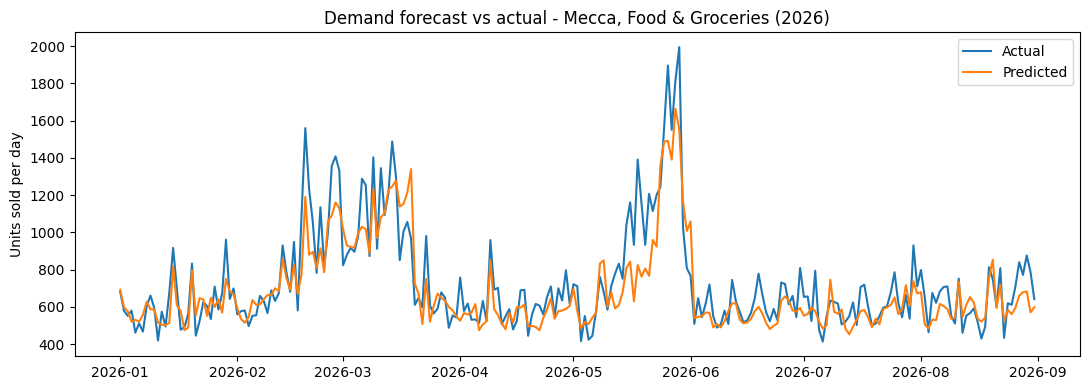

In [14]:
one = test[(test["city"] == "Mecca") & (test["category"] == "Food & Groceries")]
plt.figure(figsize=(11, 4))
plt.plot(one["date"], one[TARGET], label="Actual", linewidth=1.5)
plt.plot(one["date"], one["predicted_units"], label="Predicted", linewidth=1.5)
plt.title("Demand forecast vs actual - Mecca, Food & Groceries (2026)")
plt.ylabel("Units sold per day")
plt.legend()
plt.tight_layout()
plt.savefig("forecast_vs_actual.png", dpi=130)
plt.show()

## 10. Final model
Now that we've tested it, retrain on ALL the data and save it for the agent.

In [16]:
final_model = HistGradientBoostingRegressor(
    max_iter=400, learning_rate=0.05, max_leaf_nodes=31,
    categorical_features="from_dtype", random_state=RANDOM_STATE,
)
final_model.fit(df[FEATURES], np.log1p(df[TARGET]))
joblib.dump({"model": final_model, "features": FEATURES, "horizon_days": HORIZON}, MODEL_PATH)
test[["date", "city", "category", TARGET, "predicted_units"]].to_csv(
    "demand_test_predictions.csv", index=False)
print(f"Saved: {MODEL_PATH}, demand_test_predictions.csv, forecast_vs_actual.png")

# optional: download the saved model to your device
# files.download(MODEL_PATH)

Saved: demand_model.joblib, demand_test_predictions.csv, forecast_vs_actual.png


## 11. Predictions
A helper that returns total predicted units for a city + category over the next few days (max 7). If you give it the current stock, it also tells the agent the shortage.

*MVP version: it looks up the prepared rows for those dates, so pick dates that exist in the dataset.*

In [17]:
def forecast_demand(city, category, start_date, days=7, current_stock=None):
    days = min(days, HORIZON)
    start = pd.Timestamp(start_date)
    end = start + pd.Timedelta(days=days - 1)
    rows = df[(df["city"] == city) & (df["category"] == category) &
              (df["date"] >= start) & (df["date"] <= end)]
    if rows.empty:
        return {"error": f"No data for {city} / {category} from {start.date()}"}

    total = int(predict_units(final_model, rows).sum())
    result = {
        "city": city,
        "category": category,
        "start_date": str(start.date()),
        "days": len(rows),
        "predicted_units": total,
    }
    if current_stock is not None:
        result["current_stock"] = current_stock
        result["shortage_units"] = max(total - current_stock, 0)
    return result

In [18]:
print(forecast_demand("Jeddah", "Electronics", "2026-06-01", days=7))
print(forecast_demand("Mecca", "Food & Groceries", "2026-05-20", days=7, current_stock=3000))

{'city': 'Jeddah', 'category': 'Electronics', 'start_date': '2026-06-01', 'days': 7, 'predicted_units': 1503}
{'city': 'Mecca', 'category': 'Food & Groceries', 'start_date': '2026-05-20', 'days': 7, 'predicted_units': 8444, 'current_stock': 3000, 'shortage_units': 5444}
